In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

bank_companies = ["PRVU", "SBL", "EBL", "PCBL", "HBL"]


def clean_number(value):
    if value is None:
        return None

    value = value.strip()

    if value in ["", "-", "N/A"]:
        return None

    value = value.replace(",", "")

    try:
        return float(value)
    except:
        return None


def scrape_company(symbol):

    url = f"https://merolagani.com/CompanyDetail.aspx?symbol={symbol}"

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"Could not access {symbol}")
            return None

        soup = BeautifulSoup(response.text, "html.parser")
 
        def get_value(label):
            for tag in soup.find_all(["td", "th"]):

                if label.lower() in tag.get_text(strip=True).lower():

                    sibling = tag.find_next_sibling(["td", "th"])

                    if sibling:
                        return sibling.get_text(strip=True)

            return None

        price = get_value("Market Price")
        pe = get_value("P/E Ratio")
        pb = get_value("PBV")

        company_data = {
            "Ticker": symbol,
            "Market Price": clean_number(price),
            "P/E Ratio": clean_number(pe),
            "P/B Ratio": clean_number(pb)
        }

        return company_data

    except Exception as e:
        print("Error:", e)
        return None


all_data = []

for company in bank_companies:

    print("Scraping:", company)

    result = scrape_company(company)

    if result:
        all_data.append(result)

    time.sleep(1)

df = pd.DataFrame(all_data)

print("\nFinal Data:")
print(df)

df.to_csv("bank_data.csv", index=False)

print("\nData saved to bank_data.csv")

Scraping: PRVU
Scraping: SBL
Scraping: EBL
Scraping: PCBL
Scraping: HBL

Final Data:
  Ticker  Market Price  P/E Ratio  P/B Ratio
0   PRVU         190.0      39.42       1.30
1    SBL         388.0      22.02       1.79
2    EBL         700.0      21.64       2.87
3   PCBL         233.0      11.85       1.36
4    HBL         193.0      42.89       1.12

Data saved to bank_data.csv


In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

INSURANCE = ["NLIC", "LICN", "NLICL", "HLI"]

def clean_number(value):
    if value is None:
        return None

    value = value.strip()

    if value in ["", "-", "N/A"]:
        return None

    value = value.replace(",", "")

    try:
        return float(value)
    except:
        return None

def scrape_company(symbol):
    url = f"https://merolagani.com/CompanyDetail.aspx?symbol={symbol}"

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"Could not access {symbol}")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        def get_value(label):
            for tag in soup.find_all(["td", "th"]):
                if label.lower() in tag.get_text(strip=True).lower():
                    sibling = tag.find_next_sibling(["td", "th"])
                    if sibling:
                        return sibling.get_text(strip=True)
            return None

        price = get_value("Market Price")
        pe = get_value("P/E Ratio")
        pb = get_value("PBV")

        company_data = {
            "Ticker": symbol,
            "Market Price": clean_number(price),
            "P/E Ratio": clean_number(pe),
            "P/B Ratio": clean_number(pb)
        }

        return company_data

    except Exception as e:
        print("Error:", e)
        return None

all_data = []

for company in INSURANCE:
    print("Scraping:", company)
    result = scrape_company(company)
    
    if result:
        all_data.append(result)
        
    time.sleep(1)

df = pd.DataFrame(all_data)

print("\nFinal Data:")
print(df)

df.to_csv("insurance_data.csv", index=False)

print("\nData saved to insurance_data.csv")

Scraping: NLIC
Scraping: LICN
Scraping: NLICL
Scraping: HLI

Final Data:
  Ticker  Market Price  P/E Ratio  P/B Ratio
0   NLIC        747.50     134.44       5.92
1   LICN        804.90     103.59       4.56
2  NLICL        567.10      58.10       4.35
3    HLI        328.90      86.33       3.27

Data saved to insurance_data.csv


In [3]:
import requests
import pandas as pd

RAW_COOKIE_STRING = """.AspNetCore.Antiforgery.gbyaorGvgn0=CfDJ8ITa6UhpNmdEoUQNFVHVsFR_8HLIZqoq_uJkOVQdu8LtFuMGzaRT_DmAd8EyfSMITS5L6XMnxFy0g0oHo7VRV5TsrtRH6FRoVeMlW6OR9xA4_a1KWeLjihmrrNPKvywk9X0KsF0oMh0yAms6XDlc7KI; .AspNetCore.Identity.Application=CfDJ8ITa6UhpNmdEoUQNFVHVsFQPv9wPKVPQa41odICBc4y4NJo7HJXWl22XdUPN8J8kNWGd9HGyVtEMdMbAqL90fQ-tFOBElEFF5u1ob0z47YshzVvdeVyQCDz8JEiNEFuERaYwvP832YXKm1i4mgHBkxpw6rnNzkCAObt8EmxD6v_tEJ04ymarAMvxbNPIyRdG-2qst5MASo-zOksky1Eahl9QFmVqWGP5_elpvf6XIgXDc1fOONZC4kCgzcuVBwAun7ZzltO5wk_EykgBl59Q1TkWqG1_cjspqy8xRNbjMMHaojGrCXiMJeylynHizgPEYg6pc4gRTMM_HsDEpIVW2piHt_IgQXnNzDqQzWN4FgA3r6EiHca84qAXqX3q_s4DXnWi7zPFQ-Jvuv1ZREMng_TzOn3FIn4OQ0D0CCHxtYURPEDvnUpGz_wxoalLSP1ZUKSrxzId41s4g-W_YpQRN7MTtVauIeVNKgdbef3S-VYvsoRQ-bsclZWOOYzTF5JXDupaCWxxffjMJDUQGk5DCdEC4ZXWQj2eofxR5eClTgeJ5Rf_9X58QLunuZwVxukomi-BML77BgXFI66nIGvp4UJTqI_JQikVABZKXurJYZTPU9sm9R-ft2A90gW10flCiK39mcDmwhMukmWyjK60UQUZPquyE_8ryj2lF_FqwITVat7c6VVAaI-66OuZ7coXBPYzScVdo0toFNIK4ybP3d8nk9K11bJPDzPJCy--sDSpND6fqwKYilk94JXzRbnQCuj3XhuAOuAf5Oi04wITGEsSzlmy6Yko5BDspMQ4X1eoaRsUB5ogXa01gQDlIlFLijYcM3kxEFhPoyfBDmC1vkGe6Lek49HMkc7iP06K0Gjs0hokpeDXxnrLqf2r0V7aKTx7C6lhbuzYpj-gbkAzA_ljLyT6tA0Tnpkf3ZjUdvD3x8ADDmO_WHwzPCuCG8dwPw"""

cookie_dict = {}
for cookie in RAW_COOKIE_STRING.split(";"):
    if "=" in cookie:
        key, val = cookie.strip().split("=", 1)
        cookie_dict[key] = val

url = "https://login.capitalmax.com.np/Api/GetFinancialComparison"

payload = {
    "companies": "CHCL|MANDU|MHNL|SHPC|USHEC",
    "sector": "Hydro Power",
    "timeline": "Quarterly",
    "period": "YTD",
    "nature": "company",
    "dataSampleCount": 1,
    "dataPrecision": 1000,
    "fiscalYearId": "37",
    "quarterNo": "Q3",
    "comparisonType": "Q2Q",
    "reportType": "Key Financials"
}

print("Extracting minimalist data map...")
response = requests.post(url, json=payload, cookies=cookie_dict)

if response.status_code == 200:
    data = response.json()
    if "companyData" in data:
        rows = []
        for company in data["companyData"]:
            for item in company.get("financials", []):
                rows.append({
                    "symbol": company.get("stockSymbol"),
                    "metric": item.get("itemName"),
                    "value": item.get("itemValue")
                })

        df_raw = pd.DataFrame(rows)


        df_grid = df_raw.pivot_table(
            index="metric",
            columns="symbol",
            values="value"
        ).reset_index()

        df_grid.columns.name = None
        output_filename = "hydropowers_grid_view.csv"
        df_grid.to_csv(output_filename, index=False, float_format='%.2f')

        print(f"\n Clean matrix generated without type or index headers!")
        print(f" File compiled to: '{output_filename}'\n")

        # 4. Set floating point presentation format for cleaner notebook display
        pd.set_option('display.float_format', lambda x: '%.2f' % x)
        display(df_grid.head(20))
    else:
        print("Server parsed request successfully but data blocks are missing.")
else:
    print(f"Connection drops. Backend responded with HTTP {response.status_code}")

Extracting minimalist data map...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [4]:
import pandas as pd

def clean_number(value):
    if value is None or pd.isna(value):
        return None
    val_str = str(value).strip()
    if val_str in ["", "-", "N/A", "nan"]:
        return None
    val_str = val_str.replace(",", "")
    try:
        return float(val_str)
    except ValueError:
        return None

def clean_hydropower_sheet(input_path, output_path):
    try:
        df = pd.read_csv(input_path)
    except FileNotFoundError:
        print(f"[Error]: The file '{input_path}' was not found.")
        return None

    df['metric'] = df['metric'].str.strip()

    target_rows = {
        'long term debt': 'Long Term Debt',
        'operating profit': 'EBITDA',
        'cash': 'Cash and Cash Equivalent',
        'market cap': 'Market Capitalization'
    }

    cleaned_rows = []
    for key, standard_name in target_rows.items():
        row = df[df['metric'].str.lower().str.contains(key)]
        if not row.empty:
            row = row.copy()
            row['metric'] = standard_name
            cleaned_rows.append(row)

    if not cleaned_rows:
        return None

    filtered_df = pd.concat(cleaned_rows).set_index('metric')

    for col in filtered_df.columns:
        filtered_df[col] = filtered_df[col].apply(clean_number)

    filtered_df.to_csv(output_path)
    return filtered_df

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

final_table = clean_hydropower_sheet('hydropowers_grid_view.csv', 'hydropowers_clean.csv')

if final_table is not None:
    print(final_table)

                                  CHCL         MANDU         MHNL  \
metric                                                              
Long Term Debt              183,979.64  2,895,618.86 2,469,107.71   
EBITDA                      593,973.94    511,819.86   178,123.45   
Cash and Cash Equivalent    111,458.26      3,771.68       622.86   
Market Capitalization    45,243,396.00 11,222,732.51 3,125,000.00   

                                  SHPC        USHEC  
metric                                               
Long Term Debt              121,975.22 2,989,560.66  
EBITDA                      299,705.86   526,257.43  
Cash and Cash Equivalent    234,925.98   117,823.68  
Market Capitalization    18,536,710.81 6,632,550.00  


COMMERCIAL BANKS RELATIVE VALUATION
Benchmark Medians: P/E: 22.02, P/B: 1.36, Graham: 48.04

Ticker  Market Price  P/E Ratio  P/B Ratio  Graham Blended OVERALL STATUS
  PRVU        190.00      39.42       1.30           51.25     OVERVALUED
   SBL        388.00      22.02       1.79           39.42    UNDERVALUED
   EBL        700.00      21.64       2.87           62.11     OVERVALUED
  PCBL        233.00      11.85       1.36           16.12    UNDERVALUED
   HBL        193.00      42.89       1.12           48.04     OVERVALUED


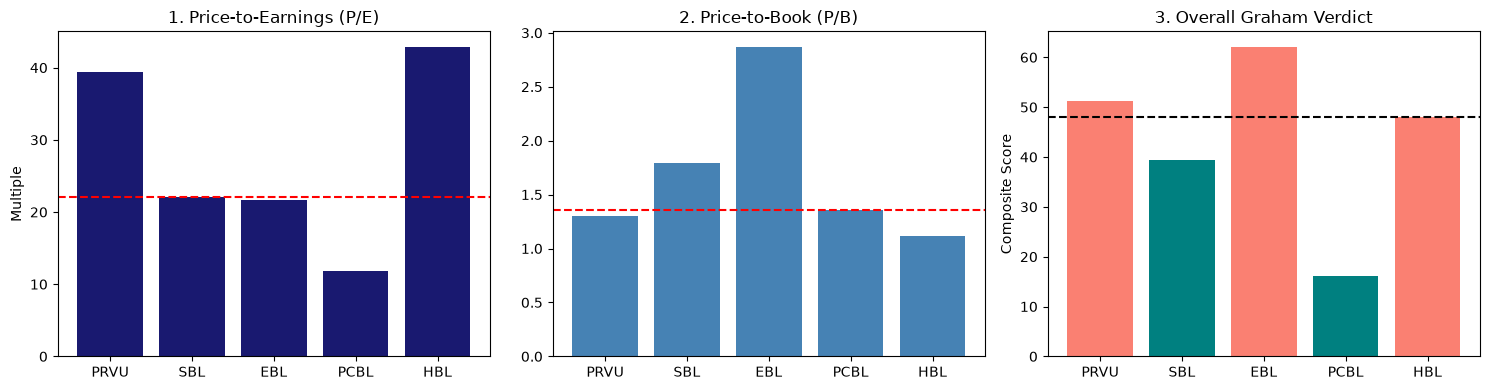

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bank_data.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

pe_med = df['P/E Ratio'].median()
pb_med = df['P/B Ratio'].median()

pe_signals = []
pb_signals = []
graham_scores = []
overall_status = []

for i in range(len(df)):
    current_pe = df.loc[i, 'P/E Ratio']
    if current_pe < pe_med:
        pe_signals.append('Under')
    else:
        pe_signals.append('Over')

    current_pb = df.loc[i, 'P/B Ratio']
    if current_pb < pb_med:
        pb_signals.append('Under')
    else:
        pb_signals.append('Over')

    blended_calc = current_pe * current_pb
    graham_scores.append(blended_calc)

df['PE Signal'] = pe_signals
df['PB Signal'] = pb_signals
df['Graham Blended'] = graham_scores

blended_med = df['Graham Blended'].median()

for i in range(len(df)):
    current_score = df.loc[i, 'Graham Blended']
    if current_score < blended_med:
        overall_status.append('UNDERVALUED')
    else:
        overall_status.append('OVERVALUED')

df['OVERALL STATUS'] = overall_status

print("COMMERCIAL BANKS RELATIVE VALUATION")
print(f"Benchmark Medians: P/E: {round(pe_med, 2)}, P/B: {round(pb_med, 2)}, Graham: {round(blended_med, 2)}\n")
cols_to_show = ['Ticker', 'Market Price', 'P/E Ratio', 'P/B Ratio', 'Graham Blended', 'OVERALL STATUS']
print(df[cols_to_show].to_string(index=False))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.bar(df['Ticker'], df['P/E Ratio'], color='midnightblue')
plt.axhline(pe_med, color='red', linestyle='--')
plt.title('1. Price-to-Earnings (P/E)')
plt.ylabel('Multiple')

plt.subplot(1, 3, 2)
plt.bar(df['Ticker'], df['P/B Ratio'], color='steelblue')
plt.axhline(pb_med, color='red', linestyle='--')
plt.title('2. Price-to-Book (P/B)')

bar_colors = []
for status in df['OVERALL STATUS']:
    if status == 'UNDERVALUED':
        bar_colors.append('teal')
    else:
        bar_colors.append('salmon')

plt.subplot(1, 3, 3)
plt.bar(df['Ticker'], df['Graham Blended'], color=bar_colors)
plt.axhline(blended_med, color='black', linestyle='--')
plt.title('3. Overall Graham Verdict')
plt.ylabel('Composite Score')

plt.tight_layout()
plt.show()

LIFE INSURANCES RELATIVE VALUATION
Benchmark Medians: P/E: 94.96, P/B: 4.46, Graham: 377.33

Ticker  P/E Ratio  P/B Ratio  Graham Blended OVERALL STATUS
  NLIC     134.44       5.92          795.88     OVERVALUED
  LICN     103.59       4.56          472.37     OVERVALUED
 NLICL      58.10       4.35          252.73    UNDERVALUED
   HLI      86.33       3.27          282.30    UNDERVALUED


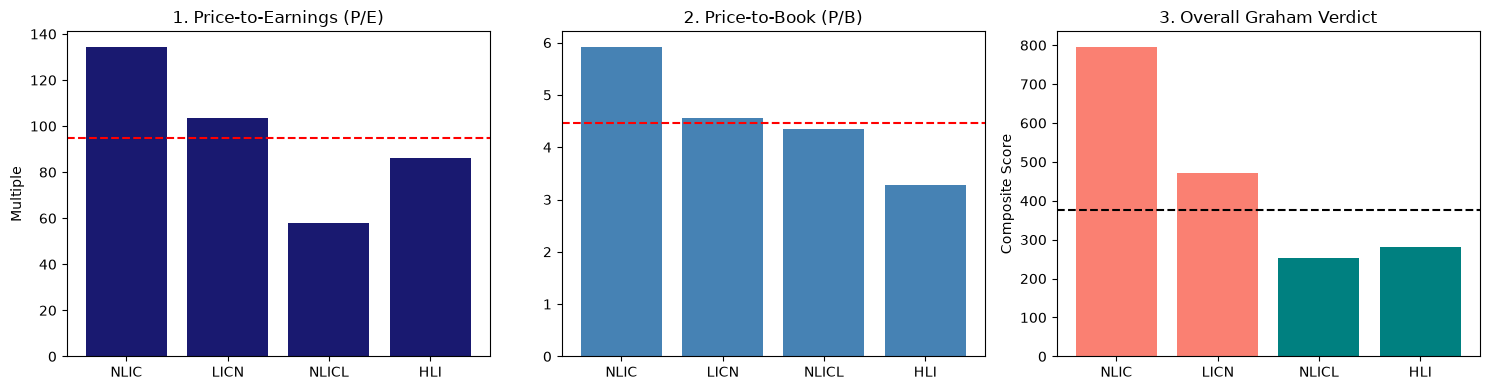

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('insurance_data.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

pe_med = df['P/E Ratio'].median()
pb_med = df['P/B Ratio'].median()

pe_signals = []
pb_signals = []
graham_scores = []
overall_status = []

for i in range(len(df)):
    current_pe = df.loc[i, 'P/E Ratio']
    if current_pe < pe_med:
        pe_signals.append('Under')
    else:
        pe_signals.append('Over')

    current_pb = df.loc[i, 'P/B Ratio']
    if current_pb < pb_med:
        pb_signals.append('Under')
    else:
        pb_signals.append('Over')

    blended_calc = current_pe * current_pb
    graham_scores.append(blended_calc)

df['PE Signal'] = pe_signals
df['PB Signal'] = pb_signals
df['Graham Blended'] = graham_scores

blended_med = df['Graham Blended'].median()

for i in range(len(df)):
    current_score = df.loc[i, 'Graham Blended']
    if current_score < blended_med:
        overall_status.append('UNDERVALUED')
    else:
        overall_status.append('OVERVALUED')

df['OVERALL STATUS'] = overall_status

print("LIFE INSURANCES RELATIVE VALUATION")
print(f"Benchmark Medians: P/E: {round(pe_med, 2)}, P/B: {round(pb_med, 2)}, Graham: {round(blended_med, 2)}\n")
cols_to_show = ['Ticker', 'P/E Ratio', 'P/B Ratio', 'Graham Blended', 'OVERALL STATUS']
print(df[cols_to_show].to_string(index=False))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.bar(df['Ticker'], df['P/E Ratio'], color='midnightblue')
plt.axhline(pe_med, color='red', linestyle='--')
plt.title('1. Price-to-Earnings (P/E)')
plt.ylabel('Multiple')

plt.subplot(1, 3, 2)
plt.bar(df['Ticker'], df['P/B Ratio'], color='steelblue')
plt.axhline(pb_med, color='red', linestyle='--')
plt.title('2. Price-to-Book (P/B)')

bar_colors = []
for status in df['OVERALL STATUS']:
    if status == 'UNDERVALUED':
        bar_colors.append('teal')
    else:
        bar_colors.append('salmon')

plt.subplot(1, 3, 3)
plt.bar(df['Ticker'], df['Graham Blended'], color=bar_colors)
plt.axhline(blended_med, color='black', linestyle='--')
plt.title('3. Overall Graham Verdict')
plt.ylabel('Composite Score')

plt.tight_layout()
plt.show()

HYDROPOWER COMPANIES RELATIVE VALUATION
Sector Benchmark Median EV/EBITDA: 31.4

Ticker  Enterprise Value      EBITDA  EV/EBITDA      STATUS
  CHCL      45315917.380 593973.9400  76.292770  OVERVALUED
 MANDU      14114579.689 511819.8640  27.577241 UNDERVALUED
  MHNL       5593484.852 178123.4520  31.402293  OVERVALUED
  SHPC      18423760.048 299705.8630  61.472805  OVERVALUED
 USHEC       9504286.979 526257.4294  18.060148 UNDERVALUED


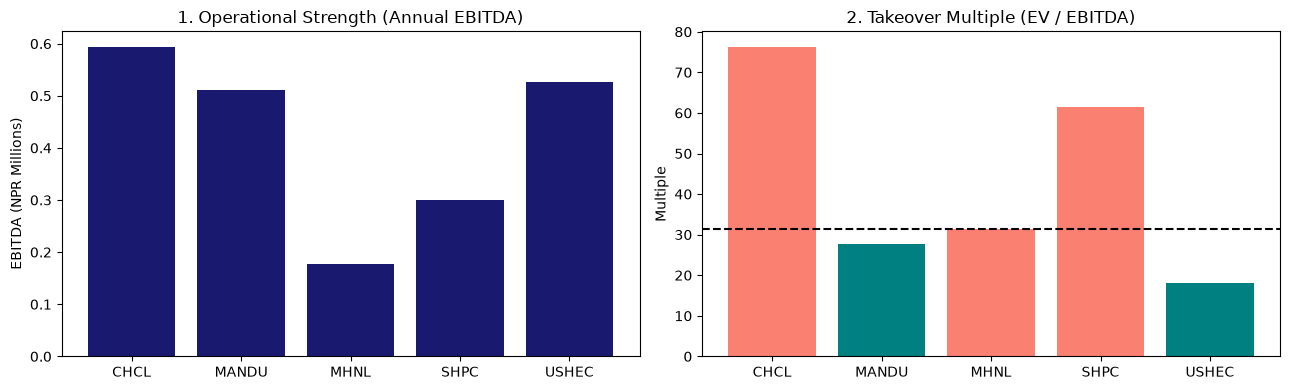

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hydropowers_clean.csv', encoding='utf-8-sig', index_col='metric')

df = df.T

df.index.name = 'Ticker'
df = df.reset_index()
df.columns = df.columns.str.strip()

num_cols = ['Long Term Debt', 'EBITDA', 'Cash and Cash Equivalent', 'Market Capitalization']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Enterprise Value'] = (
    df['Market Capitalization']
    + df['Long Term Debt']
    - df['Cash and Cash Equivalent']
)

df['EV/EBITDA'] = df['Enterprise Value'] / df['EBITDA']

ev_median = df['EV/EBITDA'].median()

overall_status = []

for i in range(len(df)):
    current_mult = df.loc[i, 'EV/EBITDA']
    if current_mult < ev_median:
        overall_status.append('UNDERVALUED')
    else:
        overall_status.append('OVERVALUED')

df['STATUS'] = overall_status

print("HYDROPOWER COMPANIES RELATIVE VALUATION")
print(f"Sector Benchmark Median EV/EBITDA: {round(ev_median, 2)}\n")
report_cols = ['Ticker', 'Enterprise Value', 'EBITDA', 'EV/EBITDA', 'STATUS']
print(df[report_cols].to_string(index=False))

plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
plt.bar(df['Ticker'], df['EBITDA'] / 1e6, color='midnightblue')
plt.title('1. Operational Strength (Annual EBITDA)')
plt.ylabel('EBITDA (NPR Millions)')

bar_colors = []
for status in df['STATUS']:
    if status == 'UNDERVALUED':
        bar_colors.append('teal')
    else:
        bar_colors.append('salmon')

plt.subplot(1, 2, 2)
plt.bar(df['Ticker'], df['EV/EBITDA'], color=bar_colors)
plt.axhline(ev_median, color='black', linestyle='--')
plt.title('2. Takeover Multiple (EV / EBITDA)')
plt.ylabel('Multiple')

plt.tight_layout()
plt.show()